<a href="https://colab.research.google.com/github/Daybreak53/HealthEat-Pill-Detection/blob/feature%2Fmodel-data-processing/yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

데이터 불러오기

In [1]:
!pip install kagglehub

In [3]:
import os
from google.colab import userdata # 코랩의 시크릿 모드(Secrets Manager)를 써서 API를 불러옴
import kagglehub

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME') # secret 모드에 KAGGLE_USERNAME 할당
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY') # secret 모드에 KAGGLE_KEY 할당

path = kagglehub.competition_download('ai09-level1-project')
print(f'path : {path}')

100%|██████████| 1.79G/1.79G [00:17<00:00, 108MB/s]

Extracting files...


path : /root/.cache/kagglehub/competitions/ai09-level1-project


In [4]:
import os
import glob
import pandas as pd

#  기본 경로 설정 (kagglehub에서 리턴해준 path 사용)
base_path = path

# train image, test image, train_annotation 경로 바꾸기
train_img_dir = os.path.join(base_path, 'sprint_ai_project1_data', 'train_images')
train_anno_dir = os.path.join(base_path, 'sprint_ai_project1_data', 'train_annotations')
test_img_dir = os.path.join(base_path, 'sprint_ai_project1_data', 'test_images')

print(f"Train 이미지 경로: {train_img_dir}")
print(f"Train 어노테이션 경로: {train_anno_dir}")
print(f"Test 이미지 경로: {test_img_dir}")

Train 이미지 경로: /root/.cache/kagglehub/competitions/ai09-level1-project/sprint_ai_project1_data/train_images
Train 어노테이션 경로: /root/.cache/kagglehub/competitions/ai09-level1-project/sprint_ai_project1_data/train_annotations
Test 이미지 경로: /root/.cache/kagglehub/competitions/ai09-level1-project/sprint_ai_project1_data/test_images


test 파일

In [33]:
# 테스트 이미지(정답 없음)는 별도로 리스트업
test_images = glob.glob(os.path.join(test_img_dir, "*.png"))
print(f"테스트용 데이터: {len(test_images)}")

테스트용 데이터: 842


In [47]:
# yolo label의 경로 설정
output_label_dir = os.path.join(base_path, 'dataset/labels/train')
os.makedirs(output_label_dir, exist_ok=True)

클래스 간 불균형 파악

In [56]:
import json
from collections import Counter
import matplotlib.pyplot as plt

all_categories = []

for anno_path in df['anno_path']:
  with open(anno_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

    for anno in data['annotations']:
      categories = anno['category_id']
      all_categories.append(categories)

category_counts = Counter(all_categories)
print(f"수집된 카테고리 총 개수: {len(all_categories)}")
print(f"고유 카테고리 종류: {len(category_counts)}")
print(category_counts)

수집된 카테고리 총 개수: 763
고유 카테고리 종류: 56
Counter({3351: 153, 3483: 45, 35206: 37, 16262: 23, 21325: 22, 16232: 21, 20238: 20, 3832: 20, 36637: 19, 38162: 18, 29667: 18, 16548: 18, 19232: 17, 41768: 16, 20014: 16, 22074: 16, 33880: 16, 18147: 15, 13900: 15, 1900: 15, 32310: 14, 18357: 13, 25469: 12, 27733: 12, 31863: 12, 25367: 12, 20877: 12, 30308: 9, 28763: 9, 22347: 9, 2483: 9, 16688: 8, 3544: 6, 12778: 6, 25438: 6, 19861: 6, 19607: 6, 29345: 6, 4543: 5, 27993: 3, 34597: 3, 12247: 3, 27926: 3, 21771: 3, 13395: 3, 3743: 3, 19552: 3, 22362: 3, 29451: 3, 12081: 3, 27777: 3, 31885: 3, 24850: 3, 33009: 3, 16551: 3, 33208: 3})


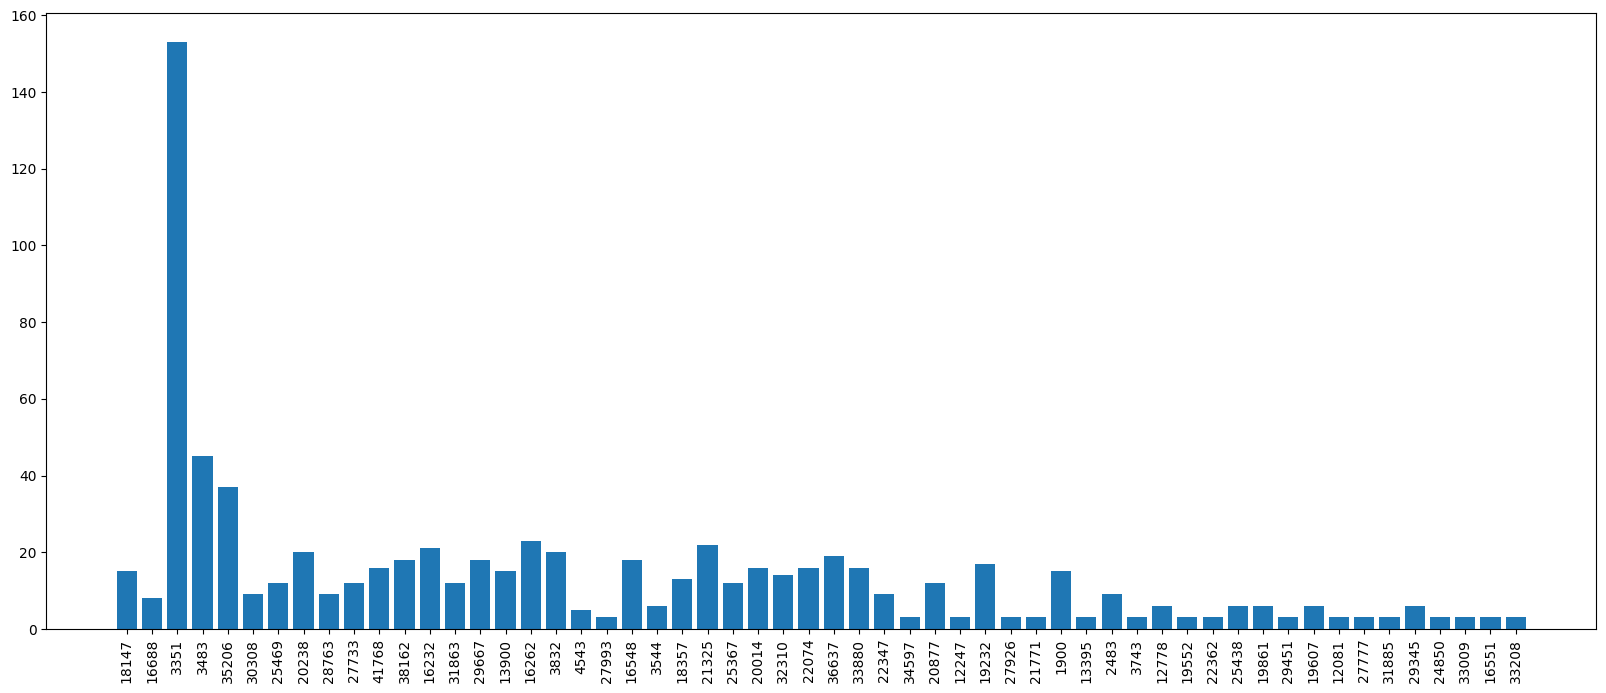

In [57]:
labels = list(map(str, category_counts.keys())) # 숫자를 문자열로 변환 (가독성)
values = list(category_counts.values())

plt.figure(figsize=(20, 8))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.show()

 BBox 크기 및 비율 분석

Text(0.5, 1.0, 'aspect ratio')

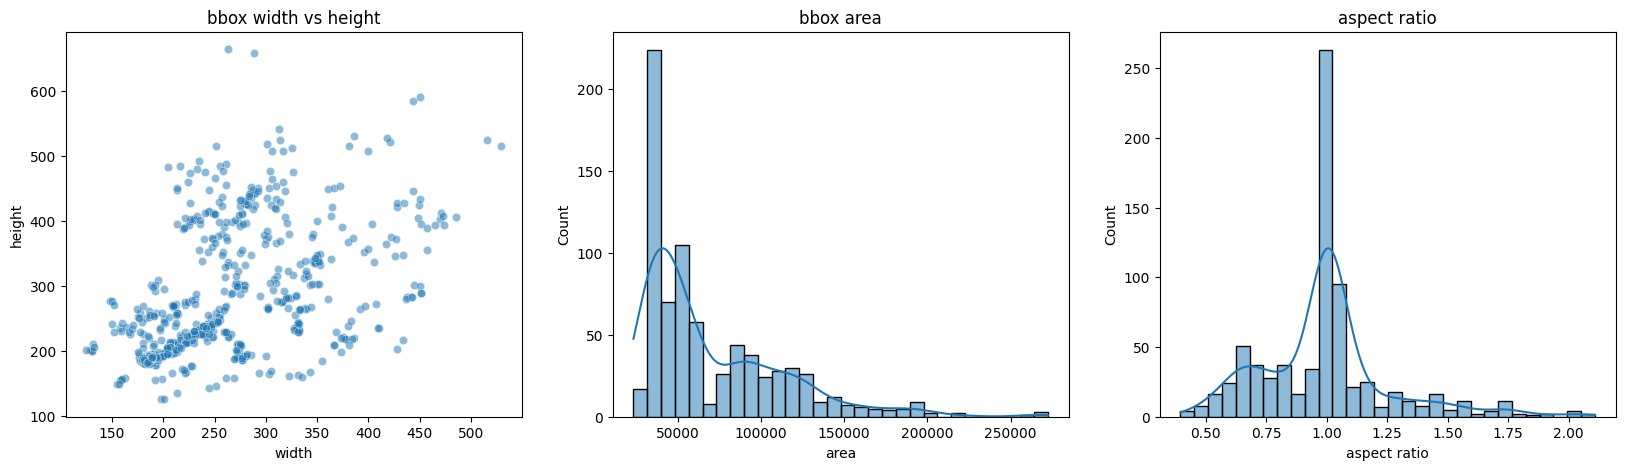

In [59]:
all_bbox= []

for anno_path in df['anno_path']:
  with open(anno_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

    for anno in data['annotations']:
      bbox = anno['bbox']
      w = bbox[2]
      h = bbox[3]
      all_bbox.append(
          {'width' : w,
           'height' : h,
           'area' : w * h,
           'aspect ratio' : w/h}
      )

bbox_df = pd.DataFrame(all_bbox)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,5))

# width, height의 산점도
plt.subplot(1,3,1)
sns.scatterplot(data=bbox_df, x = 'width', y = 'height', alpha = 0.5)
plt.title('bbox width vs height')

# 면적
plt.subplot(1,3,2)
sns.histplot(data=bbox_df['area'], kde=True, bins=30)
plt.title('bbox area')

# 가로 세로 비율
plt.subplot(1,3,3)
sns.histplot(data=bbox_df['aspect ratio'], kde=True, bins=30)
plt.title('aspect ratio')

YOLO 형식으로 변환, bbox의 이상치 제거

In [60]:
import os
import json

#  모든 JSON 어노테이션 파일 수집
all_annotations = glob.glob(os.path.join(train_anno_dir, "**/*.json"), recursive=True)

# 이미지와 어노테이션 매칭하여 리스트 만들기
data_rows = []
for anno_path in all_annotations:
    # 파일명 추출 (예: 'K-001.json' -> 'K-001.png')
    file_name = os.path.basename(anno_path).replace('.json', '.png')
    img_path = os.path.join(train_img_dir, file_name)

    # 이미지가 실제로 존재하는 경우에만 리스트에 추가 (데이터 정합성 체크)
    if os.path.exists(img_path):
        data_rows.append({
            'image_path': img_path,
            'anno_path': anno_path,
            'file_name': file_name
        })

# 데이터프레임으로 변환하여 관리
df = pd.DataFrame(data_rows)

for anno_path in df['anno_path']:
    with open(anno_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # category mapping
    categories = data['categories']
    cat_id_map = {cat['id']: i for i, cat in enumerate(categories)}

    # image mapping
    img_info = {img['id']: img for img in data['images']}

    # 이미지별로 라벨 따로 저장해야 함
    label_dict = {}

    for anno in data['annotations']:
        image_id = anno['image_id']
        bbox = anno['bbox']
        category_id = anno['category_id']

        img = img_info[image_id]
        img_w, img_h = img['width'], img['height']
        file_name = img['file_name']

        x_min, y_min, w, h = bbox

        # YOLO 변환
        x_center = (x_min + w / 2) / img_w
        y_center = (y_min + h / 2) / img_h
        w /= img_w
        h /= img_h

        #  이상치 제거
        if w <= 0 or h <= 0: # 이미지를 벗어난 박스
            continue

        if w * h < 0.0005: # 이미지에서 너무 작은 객체이므로 제거
            continue

        if not (0 <= x_center <= 1 and 0 <= y_center <= 1): # 이미지를 벗어난 박스
            continue

        aspect_ratio = w / h if h != 0 else 0
        if aspect_ratio > 10 or aspect_ratio < 0.1: # 박스의 비율이 비정상적인 경우
            continue

        if category_id not in cat_id_map: # category가 매칭되지 않는 경우
            continue

        class_id = cat_id_map[category_id]

        # 이미지별로 저장
        if file_name not in label_dict:
            label_dict[file_name] = []

        label_dict[file_name].append(
            f"{class_id} {x_center} {y_center} {w} {h}"
        )

    # 한 번에 저장 (중요)
    for file_name, lines in label_dict.items():
        txt_name = os.path.splitext(file_name)[0] + '.txt'
        txt_path = os.path.join(output_label_dir, txt_name)

        with open(txt_path, 'w') as f:
            f.write("\n".join(lines))

이미지, 라벨 정리

In [49]:
import os
import shutil
from sklearn.model_selection import train_test_split

# 이미지 리스트
image_files = df['file_name'].tolist()

train_files, val_files = train_test_split(image_files, test_size=0.2, random_state=42)

# 폴더 생성
for split in ['train', 'val']:
    os.makedirs(f'dataset/images/{split}', exist_ok=True)
    os.makedirs(f'dataset/labels/{split}', exist_ok=True)

# 파일 이동
for split, files in zip(['train', 'val'], [train_files, val_files]):
    for file_name in files:
        img_src = os.path.join(train_img_dir, file_name)
        label_src = os.path.join(output_label_dir, file_name.replace('.png', '.txt'))

        img_dst = f'dataset/images/{split}/{file_name}'
        label_dst = f'dataset/labels/{split}/{file_name.replace(".png", ".txt")}'

        shutil.copy(img_src, img_dst)

        if os.path.exists(label_src):
            shutil.copy(label_src, label_dst)

yaml 작성

In [64]:
import yaml

# category 이름 리스트 만들기
names = [cat['name'] for cat in categories]

data_yaml = {
    'path': 'dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': {i: name for i, name in enumerate(names)}
}

with open('dataset.yaml', 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

모델 학습

In [ ]:
!pip install ultralytics import YOLO

In [ ]:
model = YOLO('yolo11n.pt')

model.train(
    data='dataset.yaml',
    epochs=50,
    imgsz=640, # 이미지 크기 조절

    hsv_h=0.015, # 색상 변화
    hsv_s=0.7, # 명암 변화
    hsv_v=0.4, # 밝기 변화

    degrees=30,      # 이미지 회전
    translate=0.1,    # 이미지 이동
    scale=0.5,        # 이미지 크기 변화
    fliplr=0.5,       # 이미지 좌우 반전
    flipud=0.5,     # 이미지 상하 반전

    mosaic=1.0, # 4장 이미지 합성
    mixup=0.2 # 두 이미지 혼합하여 일반화 성능을 높여줌
)

# 학습이 끝난 후 ..best.pt파일과 같이 가장 성능이 좋았던 모델 파일이 만들어짐
# model = YOLO('가장 성능이 좋았던 모델 파일 path')
# results = model('test파일 경로')